In [1]:
import numpy as np
import pandas as pd

In [2]:
seed1 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed1_results.tsv", sep="\t")

seed1["seed"] = [1 for i in range(len(seed1))]

In [3]:
seed2 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed2_results.tsv", sep="\t")

seed2["seed"] = [2 for i in range(len(seed2))]

In [4]:
seed3 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed3_results.tsv", sep="\t")

seed3["seed"] = [3 for i in range(len(seed3))]

In [5]:
seed4 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed4_results.tsv", sep="\t")

seed4["seed"] = [4 for i in range(len(seed4))]

In [6]:
seed5 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed5_results.tsv", sep="\t")

seed5["seed"] = [5 for i in range(len(seed5))]

In [7]:
df = pd.concat([seed1, seed2, seed3, seed4, seed5], ignore_index=True)

In [8]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions',
       'seed'],
      dtype='object')

In [9]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [10]:
df['optimization_successful'] = df['SCD'] > 30

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'seed',
       'URQ_delta', 'optimization_successful'],
      dtype='object')

In [18]:
from scipy.stats import pearsonr

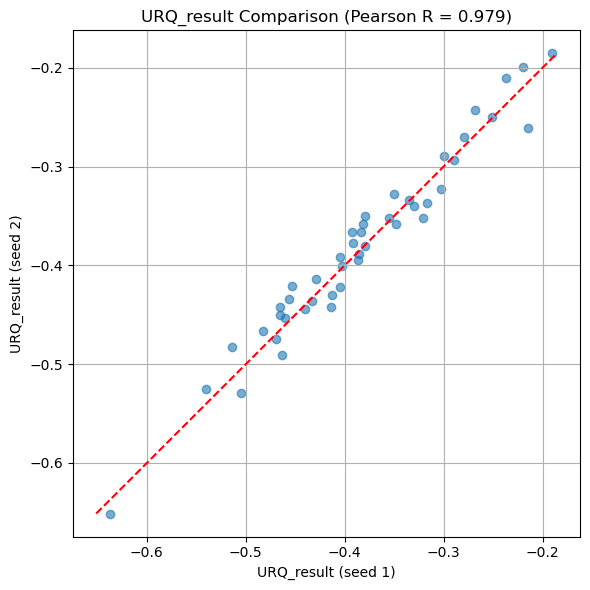

In [19]:
# Pivot to align seed 1 and seed 2 by region
pivot_df = df[df['seed'].isin([1, 2])].pivot_table(
    index=['chrom', 'start', 'end'], 
    columns='seed', 
    values='URQ_result'
).dropna()

pivot_df.columns = ['seed1', 'seed2']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed1'], pivot_df['seed2'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed1'], pivot_df['seed2'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_result (seed 1)')
plt.ylabel('URQ_result (seed 2)')
plt.title(f'URQ_result Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'seed',
       'URQ_delta', 'optimization_successful'],
      dtype='object')

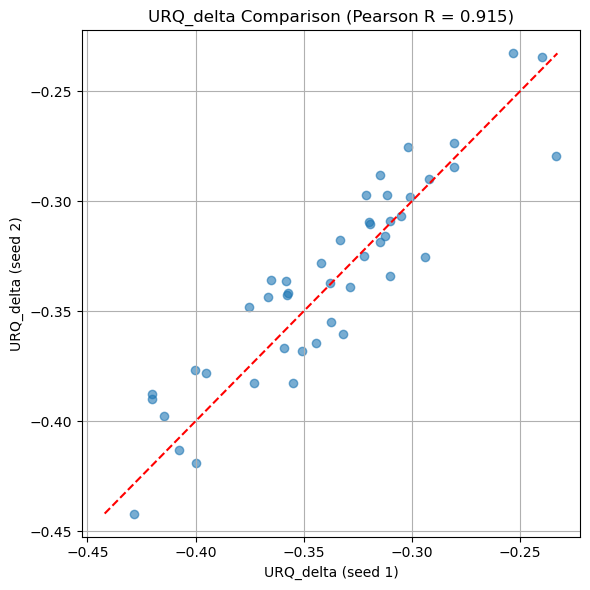

In [23]:
# Pivot to align seed 1 and seed 2 by region
pivot_df = df[df['seed'].isin([1, 2])].pivot_table(
    index=['chrom', 'start', 'end'], 
    columns='seed', 
    values='URQ_delta'
).dropna()

pivot_df.columns = ['seed1', 'seed2']

# Calculate Pearson R
r, pval = pearsonr(pivot_df['seed1'], pivot_df['seed2'])

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(pivot_df['seed1'], pivot_df['seed2'], alpha=0.6)
plt.plot([pivot_df.min().min(), pivot_df.max().max()],
         [pivot_df.min().min(), pivot_df.max().max()], 'r--')  # identity line

plt.xlabel('URQ_delta (seed 1)')
plt.ylabel('URQ_delta (seed 2)')
plt.title(f'URQ_delta Comparison (Pearson R = {r:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions', 'seed',
       'URQ_delta', 'optimization_successful'],
      dtype='object')

In [28]:
import ast

In [29]:
# If 'positions' column is a string representation of list of tuples
df['positions'] = df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [30]:
region_cols = ['chrom', 'centered_start', 'centered_end']
aligned_df = df.pivot_table(index=region_cols, columns='seed', values=['orientation', 'positions'], aggfunc='first')
aligned_df = aligned_df.dropna()  # keep only complete pairs

In [32]:
def compute_matching_motifs(positions1, orientations1, positions2, orientations2):
    count = 0
    for i, (pos1, ori1) in enumerate(zip(positions1, orientations1)):
        for j, (pos2, ori2) in enumerate(zip(positions2, orientations2)):
            # Same orientation
            if ori1 != ori2:
                continue

            # Compute overlap
            start1, end1 = pos1
            start2, end2 = pos2

            overlap_start = max(start1, start2)
            overlap_end = min(end1, end2)
            overlap = max(0, overlap_end - overlap_start)

            motif_len1 = end1 - start1
            motif_len2 = end2 - start2
            min_motif_len = min(motif_len1, motif_len2)

            if overlap / min_motif_len > 0.5:
                count += 1
                break  # Don't double-count motif1
    return count


In [33]:
matching_counts = []

for idx, row in aligned_df.iterrows():
    pos1 = row[('positions', 1)]
    pos2 = row[('positions', 2)]
    ori1 = row[('orientation', 1)]
    ori2 = row[('orientation', 2)]

    if len(pos1) != len(ori1) or len(pos2) != len(ori2):
        continue  # skip malformed rows

    match = compute_matching_motifs(pos1, ori1, pos2, ori2)
    total = max(len(pos1), len(pos2))

    matching_counts.append({
        'chrom': idx[0],
        'centered_start': idx[1],
        'centered_end': idx[2],
        'matching_ctcfs': match,
        'max_ctcfs': total,
        'fraction_matched': match / total
    })

matching_df = pd.DataFrame(matching_counts)

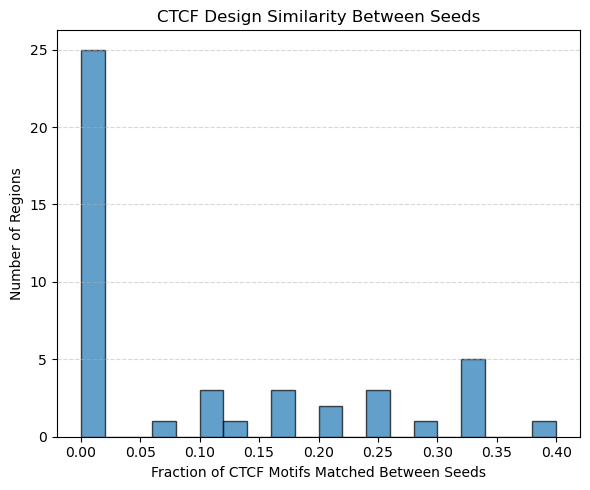

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.hist(matching_df['fraction_matched'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Fraction of CTCF Motifs Matched Between Seeds')
plt.ylabel('Number of Regions')
plt.title('CTCF Design Similarity Between Seeds')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [36]:
# aligned_df

/tmp/SLURM_987445/ipykernel_38761/3647547454.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


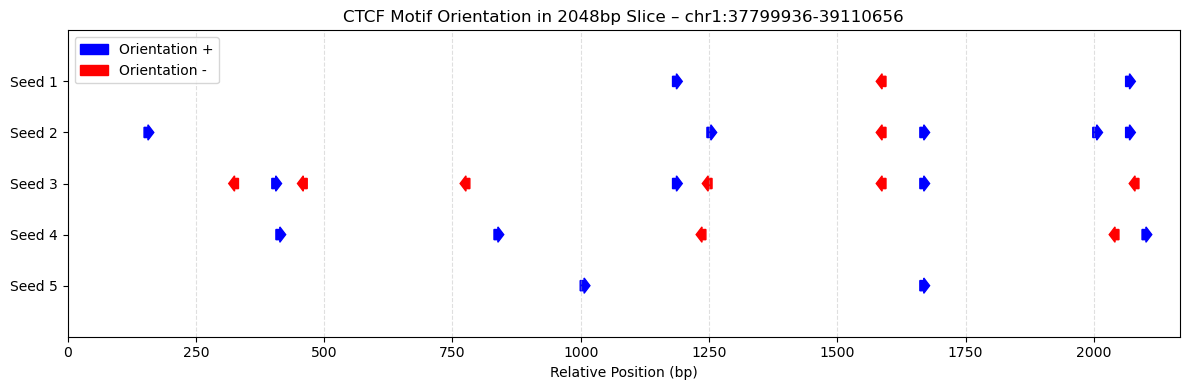

In [62]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, Patch
import ast

# --- Choose a region ---
region = ('chr1', 37799936, 39110656)  # replace with actual centered region
region_df = df[
    (df['chrom'] == region[0]) &
    (df['centered_start'] == region[1]) &
    (df['centered_end'] == region[2]) &
    (df['seed'].isin([1, 2, 3, 4, 5]))
]

# --- Parse positions if needed ---
region_df['positions'] = region_df['positions'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(12, 4))  # taller for more rows
seed_order = [5, 4, 3, 2, 1]
y_positions = {seed: idx for idx, seed in enumerate(seed_order)}  # top-down: 5 → 0

# --- Draw motifs ---
for _, row in region_df.iterrows():
    seed = row['seed']
    y = y_positions[seed]
    positions = row['positions']
    orientations = row['orientation']
    
    for (start, end), ori in zip(positions, orientations):
        color = 'blue' if ori == '+' else 'red'
        direction = 1 if ori == '+' else -1
        width = end - start
        arrow = FancyArrow(start, y, width * direction, 0,
                           width=0.2,
                           head_width=0.3,
                           head_length=min(20, width * 0.6),
                           length_includes_head=True,
                           color=color)
        ax.add_patch(arrow)

# --- Axis settings ---
ax.set_xlim(0, 2168)
ax.set_ylim(-1, len(seed_order))
ax.set_yticks([y_positions[s] for s in seed_order])
ax.set_yticklabels([f'Seed {s}' for s in seed_order])
ax.set_xlabel('Relative Position (bp)')
ax.set_title(f"CTCF Motif Orientation in 2048bp Slice – {region[0]}:{region[1]}-{region[2]}")
ax.grid(axis='x', linestyle='--', alpha=0.4)

# --- Legend ---
legend_handles = [
    Patch(color='blue', label='Orientation +'),
    Patch(color='red', label='Orientation -')
]
ax.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.show()


In [49]:
# --- Convert to dict: seed → list of (start, end, orientation) ---
motifs_by_seed = {}
for _, row in region_df.iterrows():
    motifs_by_seed[row['seed']] = [
        (start, end, ori)
        for (start, end), ori in zip(row['positions'], row['orientation'])
    ]

In [51]:
def motifs_match(m1, m2):
    start1, end1, ori1 = m1
    start2, end2, ori2 = m2

    if ori1 != ori2:
        return False

    overlap_start = max(start1, start2)
    overlap_end = min(end1, end2)
    overlap = max(0, overlap_end - overlap_start)

    len1 = end1 - start1
    len2 = end2 - start2
    min_len = min(len1, len2)

    return overlap / min_len > 0.5

In [52]:
def motifs_match(m1, m2):
    start1, end1, ori1 = m1
    start2, end2, ori2 = m2

    if ori1 != ori2:
        return False

    overlap_start = max(start1, start2)
    overlap_end = min(end1, end2)
    overlap = max(0, overlap_end - overlap_start)

    len1 = end1 - start1
    len2 = end2 - start2
    min_len = min(len1, len2)

    return overlap / min_len > 0.5

In [55]:
from itertools import combinations

In [56]:
from collections import defaultdict

# Store matches like: (seed1, idx1) → list of (seed2, idx2)
matches = defaultdict(list)

for seed_a, seed_b in combinations(motifs_by_seed.keys(), 2):
    motifs_a = motifs_by_seed[seed_a]
    motifs_b = motifs_by_seed[seed_b]

    for i, m1 in enumerate(motifs_a):
        for j, m2 in enumerate(motifs_b):
            if motifs_match(m1, m2):
                matches[(seed_a, i)].append((seed_b, j))
                matches[(seed_b, j)].append((seed_a, i))  # symmetric


In [57]:
for key in sorted(matches.keys()):
    seed, idx = key
    m1 = motifs_by_seed[seed][idx]
    print(f"Motif {idx} from seed {seed} ({m1[2]} {m1[0]}-{m1[1]}) matches with:")
    for match_seed, match_idx in matches[key]:
        m2 = motifs_by_seed[match_seed][match_idx]
        print(f"   ↳ Seed {match_seed}, motif {match_idx} ({m2[2]} {m2[0]}-{m2[1]})")

Motif 0 from seed 1 (+ 1179-1198) matches with:
   ↳ Seed 3, motif 1 (+ 1179-1198)
Motif 1 from seed 1 (+ 2062-2081) matches with:
   ↳ Seed 2, motif 4 (+ 2062-2081)
Motif 2 from seed 1 (- 1595-1614) matches with:
   ↳ Seed 2, motif 5 (- 1595-1614)
   ↳ Seed 3, motif 7 (- 1595-1614)
Motif 2 from seed 2 (+ 1661-1680) matches with:
   ↳ Seed 3, motif 2 (+ 1661-1680)
   ↳ Seed 5, motif 1 (+ 1661-1680)
Motif 4 from seed 2 (+ 2062-2081) matches with:
   ↳ Seed 1, motif 1 (+ 2062-2081)
Motif 5 from seed 2 (- 1595-1614) matches with:
   ↳ Seed 1, motif 2 (- 1595-1614)
   ↳ Seed 3, motif 7 (- 1595-1614)
Motif 0 from seed 3 (+ 398-417) matches with:
   ↳ Seed 4, motif 0 (+ 406-425)
Motif 1 from seed 3 (+ 1179-1198) matches with:
   ↳ Seed 1, motif 0 (+ 1179-1198)
Motif 2 from seed 3 (+ 1661-1680) matches with:
   ↳ Seed 2, motif 2 (+ 1661-1680)
   ↳ Seed 5, motif 1 (+ 1661-1680)
Motif 7 from seed 3 (- 1595-1614) matches with:
   ↳ Seed 1, motif 2 (- 1595-1614)
   ↳ Seed 2, motif 5 (- 1595-1614)